In [4]:
from sklearn.datasets import  load_iris

In [5]:
iris = load_iris()
X = iris.data
Y = iris.target
X.shape

(150, 4)

In [7]:
Y.shape

(150,)

In [9]:
from sklearn.model_selection import train_test_split 
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.25, random_state = 1000 )


In [11]:
from sklearn.utils import check_random_state

rs= check_random_state(1000)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.25, random_state=rs)

In [12]:
X_train.shape
Y_train.shape

(112,)

In [13]:
X_test.shape
Y_test.shape

(38,)

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression

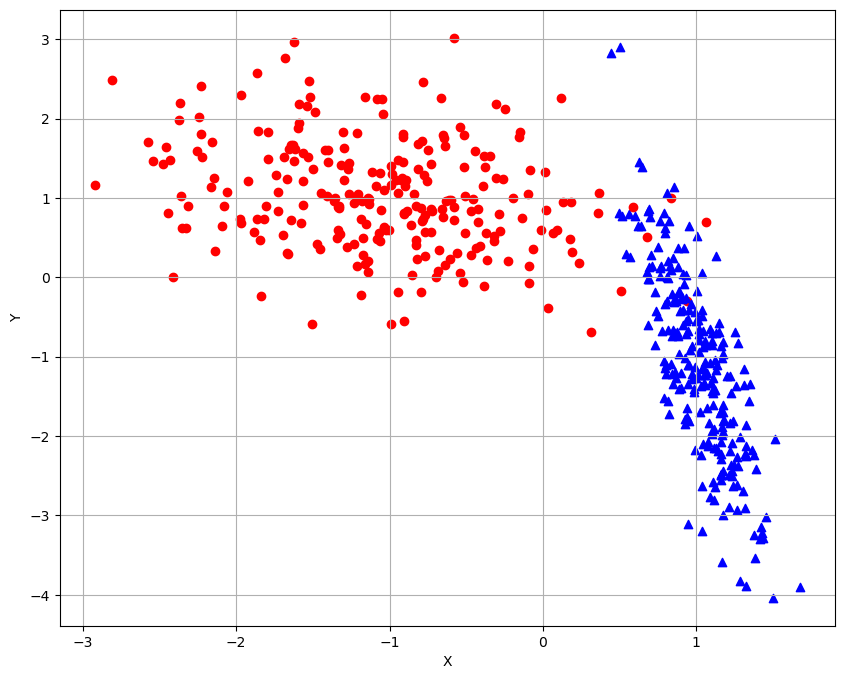

In [48]:
np.random.seed(1000)
nb_samples = 500

def show_dataset(X, Y):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))  # Reduced size for better display
    ax.grid()
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    
    for i in range(nb_samples):
        if Y[i] == 0:
            ax.scatter(X[i, 0], X[i, 1], marker='o', color='r')  # Fixed: X[i, 1] not X[1, 1]
        else:
            ax.scatter(X[i, 0], X[i, 1], marker='^', color='b')
    plt.show()

def show_classification_areas(X, Y, clf):  # Fixed: '1r' → 'clf'
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)  # Fixed: ZZ → Z and assign back to Z
    
    plt.figure(1, figsize=(10, 8))  # Reduced size
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)  # Added decision boundary
    plt.scatter(X[:, 0], X[:, 1], c=np.abs(Y), edgecolors='k', cmap=plt.cm.coolwarm)  # Fixed: Y1 → Y
    plt.xlabel('X')  # Fixed: 'x' → 'X' (consistency)
    plt.ylabel('Y')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.show()

# Fixed: Proper indentation and all parameters inside the function call
X, Y = make_classification(
    n_samples=nb_samples,
    n_features=2,
    n_clusters_per_class=1,
    n_informative=2,
    n_redundant=0
)

show_dataset(X, Y)


In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.25)
clf = LogisticRegression()
clf.fit(X_train, Y_train)


LogisticRegression()

In [32]:
clf.score(X_train, Y_train)

0.984

In [34]:
cross_val_score(clf, X, Y, scoring='accuracy', cv = 10)

array([0.96, 0.98, 1.  , 0.98, 0.98, 0.98, 0.96, 0.98, 1.  , 1.  ])

In [40]:
clf.intercept_
clf.coef_

array([[ 4.27268913, -0.66483035]])

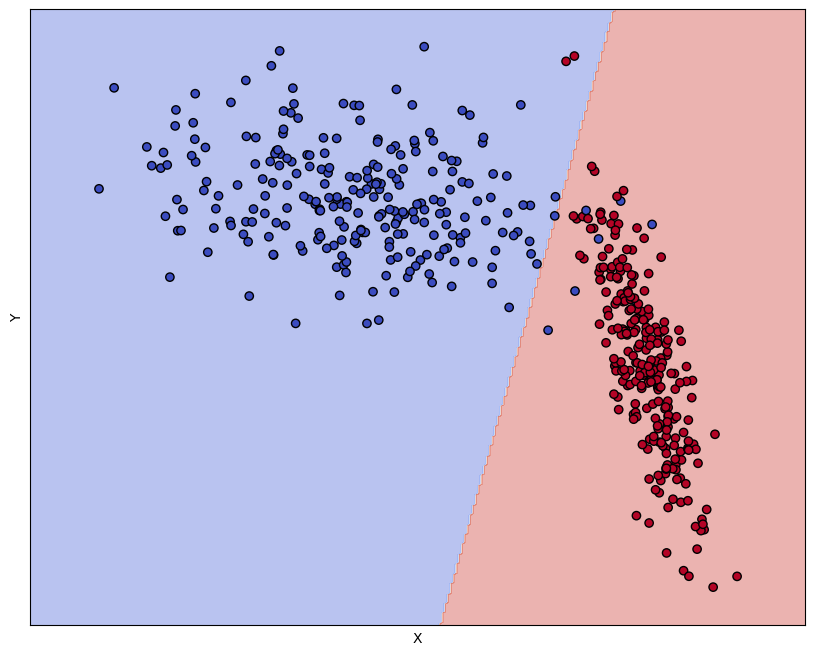

In [49]:
show_classification_areas(X,Y, clf)